In [34]:
#1.导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False



In [35]:
#2.准备数据
data=pd.read_csv(r"D:\Users\Desktop\客户流失预测\customer.csv")

print("数据集基本信息:")
print(f"数据集形状: {data.shape}")
print(f"列名: {data.columns.tolist()}")
print(f"数据类型:\n{data.dtypes.value_counts()}")
print(f"\n缺失值统计:\n{data.isnull().sum().sum()}")
print("\n重复值数量：")
print(f"重复行：{data.duplicated().sum()}")

数据集基本信息:
数据集形状: (4250, 20)
列名: ['state', 'account_length', 'area_code', 'international_plan', 'voice_mail_plan', 'number_vmail_messages', 'total_day_minutes', 'total_day_calls', 'total_day_charge', 'total_eve_minutes', 'total_eve_calls', 'total_eve_charge', 'total_night_minutes', 'total_night_calls', 'total_night_charge', 'total_intl_minutes', 'total_intl_calls', 'total_intl_charge', 'number_customer_service_calls', 'churn']
数据类型:
float64    8
int64      7
object     5
Name: count, dtype: int64

缺失值统计:
0

重复值数量：
重复行：0


In [ ]:
#3.数值型变量描述
print("数值型变量描述：")
numeric_cols=data.select_dtypes(include=[np.number]).columns
print(data[numeric_cols].describe())

数值型变量描述：
       account_length  number_vmail_messages  total_day_minutes  \
count     4250.000000            4250.000000        4250.000000   
mean       100.236235               7.631765         180.259600   
std         39.698401              13.439882          54.012373   
min          1.000000               0.000000           0.000000   
25%         73.000000               0.000000         143.325000   
50%        100.000000               0.000000         180.450000   
75%        127.000000              16.000000         216.200000   
max        243.000000              52.000000         351.500000   

       total_day_calls  total_day_charge  total_eve_minutes  total_eve_calls  \
count      4250.000000       4250.000000        4250.000000      4250.000000   
mean         99.907294         30.644682         200.173906       100.176471   
std          19.850817          9.182096          50.249518        19.908591   
min           0.000000          0.000000           0.000000        

In [ ]:
#4.分类变量描述
categorical_cols=data.select_dtypes(include=["object"]).columns
print("分类变量分布：")
for col in categorical_cols:
   print(f"\n{col}的分布：")
   print(data[col].value_counts().head())

分类变量分布：

state的分布：
state
WV    139
MN    108
ID    106
AL    101
VA    100
Name: count, dtype: int64

area_code的分布：
area_code
area_code_415    2108
area_code_408    1086
area_code_510    1056
Name: count, dtype: int64

international_plan的分布：
international_plan
no     3854
yes     396
Name: count, dtype: int64

voice_mail_plan的分布：
voice_mail_plan
no     3138
yes    1112
Name: count, dtype: int64

churn的分布：
churn
no     3652
yes     598
Name: count, dtype: int64


In [38]:
print("\n目标变量分布：")
print(data["churn"].value_counts())
#将字符串churn转换为数值型
data["churn_encoded"]=data["churn"].map({"yes":1,"no":0}) 
print(f"\n整体流失率：\n{data["churn_encoded"].mean():.2%}")


目标变量分布：
churn
no     3652
yes     598
Name: count, dtype: int64

整体流失率：
14.07%


按州/地区流失率前七项：
  state  churn_encoded
0    NJ       0.270833
1    CA       0.256410
2    WA       0.225000
3    MD       0.220930
4    MT       0.212500
5    OK       0.205128
6    NV       0.204819


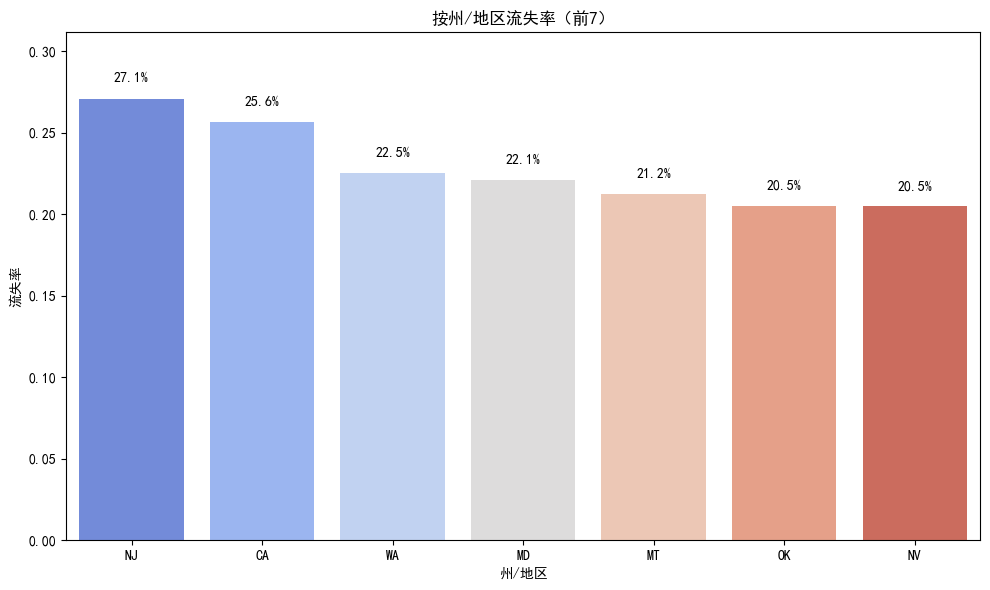

In [39]:
# 5. 按州/地区分析流失率（取前7）
churn_by_state = (
    data.groupby("state")["churn_encoded"]
    .mean()
    .sort_values(ascending=False)
    .head(7)
    .reset_index()
)

print("按州/地区流失率前七项：")
print(churn_by_state)

plt.figure(figsize=(10, 6))
sns.barplot(data=churn_by_state, x="state", y="churn_encoded", palette="coolwarm")
plt.title("按州/地区流失率（前7）")
plt.xlabel("州/地区")
plt.ylabel("流失率")
plt.ylim(0, churn_by_state["churn_encoded"].max() * 1.15)

for idx, row in churn_by_state.iterrows():
    plt.text(idx, row["churn_encoded"] + 0.01, f"{row['churn_encoded']:.1%}", ha="center")

plt.tight_layout()
plt.show()

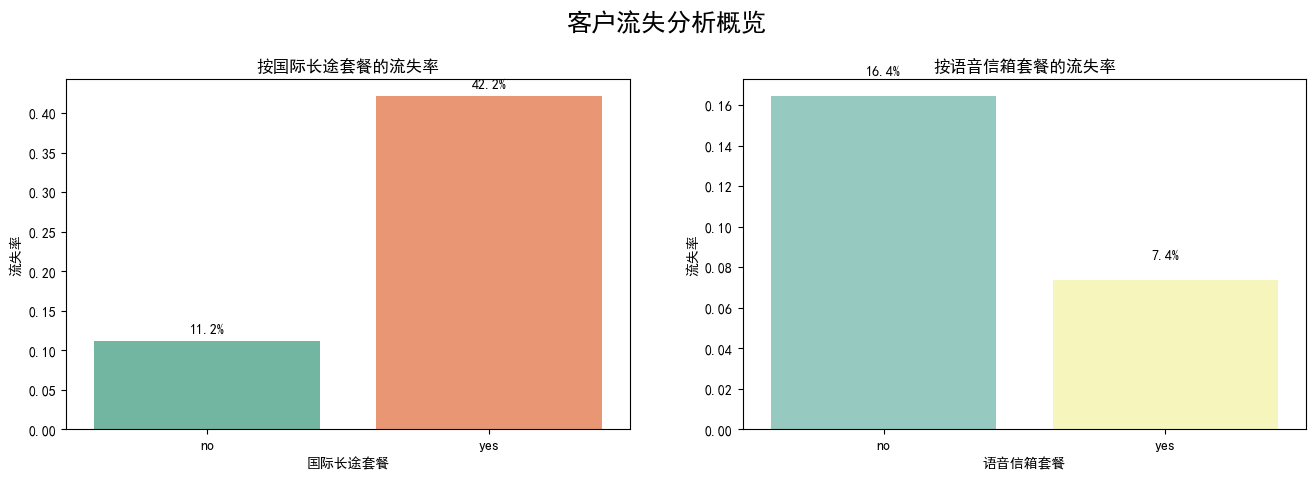

In [ ]:
# 6. 商业化客户流失分析图
plt.figure(figsize=(16, 10))
plt.suptitle("客户流失分析概览", fontsize=18, y=0.95)

# 1) 按国际长途套餐的流失率
plt.subplot(2, 2, 1)
churn_by_intl = data.groupby("international_plan")["churn_encoded"].mean().reset_index()
sns.barplot(data=churn_by_intl, x="international_plan", y="churn_encoded", palette="Set2")
plt.title("按国际长途套餐的流失率")
plt.ylabel("流失率")
plt.xlabel("国际长途套餐")
for idx, row in churn_by_intl.iterrows():
    plt.text(idx, row["churn_encoded"] + 0.01, f"{row['churn_encoded']:.1%}", ha="center")

# 2) 按语音信箱套餐的流失率
plt.subplot(2, 2, 2)
churn_by_vmail = data.groupby("voice_mail_plan")["churn_encoded"].mean().reset_index()
sns.barplot(data=churn_by_vmail, x="voice_mail_plan", y="churn_encoded", palette="Set3")
plt.title("按语音信箱套餐的流失率")
plt.ylabel("流失率")
plt.xlabel("语音信箱套餐")
for idx, row in churn_by_vmail.iterrows():
    plt.text(idx, row["churn_encoded"] + 0.01, f"{row['churn_encoded']:.1%}", ha="center")

   number_customer_service_calls  churn_encoded
0                              0       0.109481
1                              1       0.108924
2                              2       0.107709
3                              3       0.112903
4                              4       0.440191
5                              5       0.604938
6                              6       0.678571
7                              7       0.538462
8                              8       0.500000
9                              9       1.000000


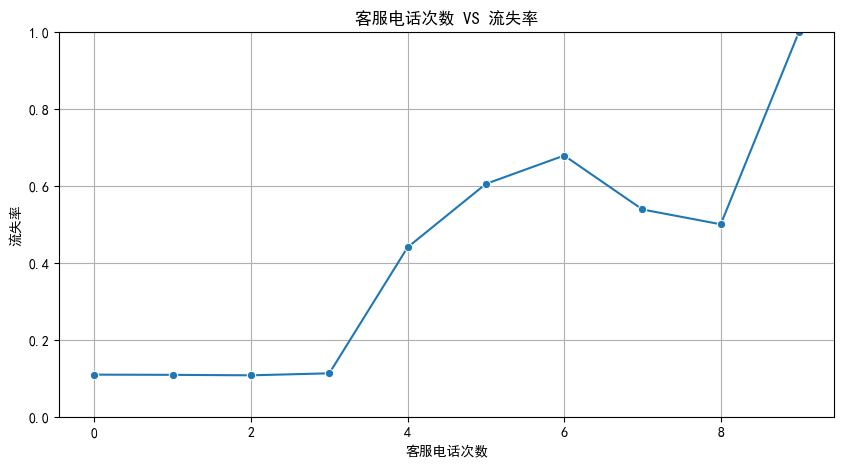

In [ ]:
# 7. 客服次数 vs 流失率
cs_churn = data.groupby("number_customer_service_calls")["churn_encoded"].mean().reset_index()
#输出流失率
print(cs_churn)
plt.figure(figsize=(10, 5))
sns.lineplot(data=cs_churn, x="number_customer_service_calls", y="churn_encoded", marker="o")
plt.title("客服电话次数 VS 流失率")
plt.xlabel("客服电话次数")
plt.ylabel("流失率")
plt.ylim(0, 1)
plt.grid(True)

  acct_len_group  churn_encoded
0           0-3月       0.125000
1           4-6月       0.000000
2          7-12月       0.055556
3           1-2年       0.135135
4           2-3年       0.118644
5           3-5年       0.118162
6          5-10年       0.148376
7         10-15年       0.139219
8          15年以上       0.142857


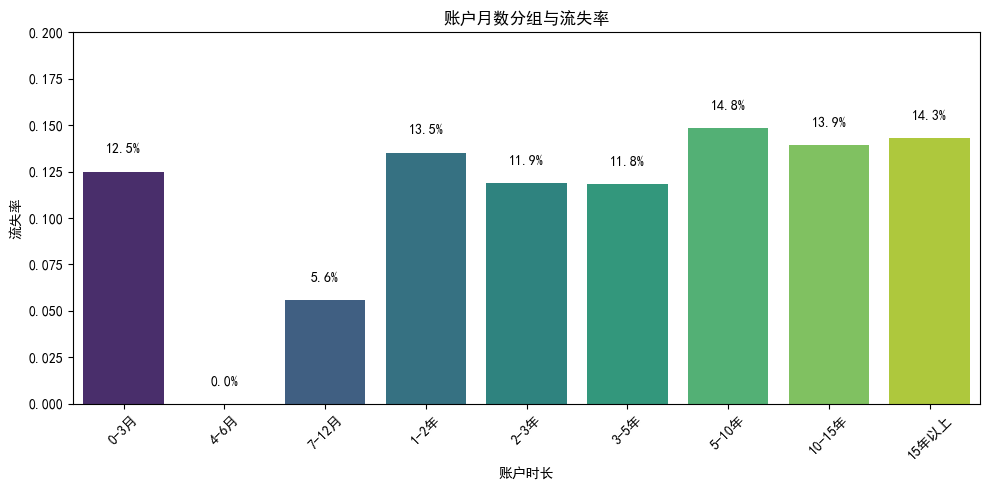

In [ ]:
#8.分组账户月数并计算流失率
plt.rcParams["font.sans-serif"]=["SimHei"]
bins = [0, 3, 6, 12, 24, 36, 60, 120, 180, 250]
labels = ["0-3月", "4-6月", "7-12月", "1-2年", "2-3年", "3-5年", "5-10年", "10-15年", "15年以上"]

data["acct_len_group"] = pd.cut(data["account_length"], bins=bins, labels=labels, include_lowest=True)
churn_by_acct_len = data.groupby("acct_len_group")["churn_encoded"].mean().reset_index()
print(churn_by_acct_len)

plt.figure(figsize=(10, 5))
sns.barplot(data=churn_by_acct_len, x="acct_len_group", y="churn_encoded", palette="viridis")
plt.title("账户月数分组与流失率")
plt.xlabel("账户时长")
plt.ylabel("流失率")
plt.ylim(0, 0.2)
for idx, row in churn_by_acct_len.iterrows():
    plt.text(idx, row["churn_encoded"] + 0.01, f"{row['churn_encoded']:.1%}", ha="center")
plt.xticks(rotation=45)
plt.tight_layout()

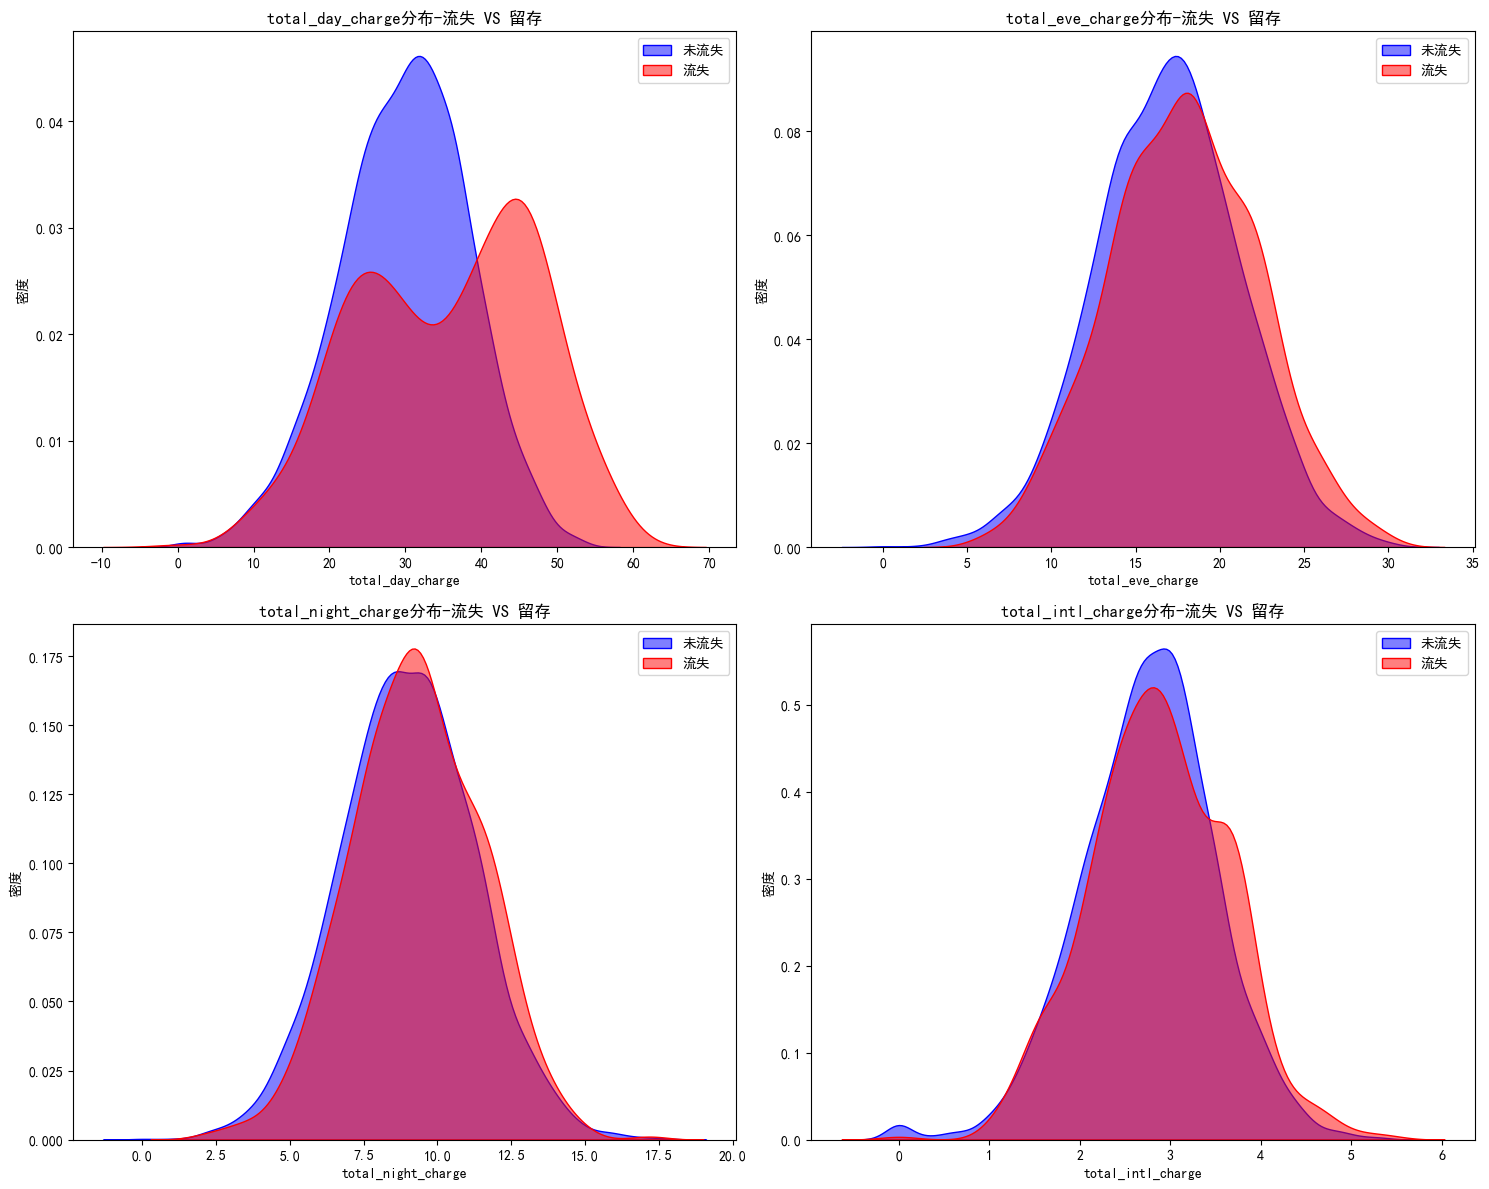

In [ ]:
#9.费用相关特征
fee_columns=["total_day_charge","total_eve_charge","total_night_charge","total_intl_charge"]
plt.figure(figsize=(15,12))
for i,col in enumerate(fee_columns,1):
    plt.subplot(2,2,i)
    not_churn_data=data.loc[data["churn"]=="no",col]
    churn_data=data.loc[data["churn"]=="yes",col]
   
    sns.kdeplot(not_churn_data,alpha=0.5,label="未流失",fill=True,color="blue")
    sns.kdeplot(churn_data,alpha=0.5,label="流失",fill=True,color="red")
    plt.title(f"{col}分布-流失 VS 留存")
    plt.xlabel(col)
    plt.ylabel("密度")
    plt.legend()
plt.tight_layout()
plt.show()     


In [ ]:
# 10.分析日间费用超过40美元的用户
count_over_40 = data[data["total_day_charge"] > 40].shape[0]
churn_rate_over_40 = data[data["total_day_charge"] > 40]["churn_encoded"].mean()
overall_churn_rate = data["churn_encoded"].mean()
percent_over_40 = (count_over_40 / len(data)) * 100


# 分析日间费用超过40美元的用户
print("分析日间费用超过40美元的用户：")
print(f"此类用户数量: {count_over_40}")
print(f"此类用户流失率: {churn_rate_over_40:.2%}")
print(f"整体流失率: {overall_churn_rate:.2%}")
print(f"此类用户占比: {percent_over_40:.2f}%")

分析日间费用超过40美元的用户：
此类用户数量: 651
此类用户流失率: 38.86%
整体流失率: 14.07%
此类用户占比: 15.32%


In [ ]:
#11.探索高价值客户的流失情况

high_value_threshold=data["total_day_charge"].quantile(0.8)
high_value_customers=data[data["total_day_charge"] > high_value_threshold]
high_value_churn_rate=high_value_customers["churn_encoded"].mean()
print(f"高价值客户（总日间费用前20%）的流失率: {high_value_churn_rate:.2%}")


高价值客户（总日间费用前20%）的流失率: 33.49%


与流失率相关的特征相关性：
number_customer_service_calls    0.221220
total_day_minutes                0.215272
total_day_charge                 0.215263
total_eve_minutes                0.078855
total_eve_charge                 0.078852
total_intl_minutes               0.055186
total_intl_charge                0.055177
total_night_minutes              0.046647
total_night_charge               0.046641
account_length                   0.019378
total_day_calls                  0.011640
total_eve_calls                 -0.006817
total_night_calls               -0.012699
total_intl_calls                -0.034334
number_vmail_messages           -0.100347
Name: churn_encoded, dtype: float64


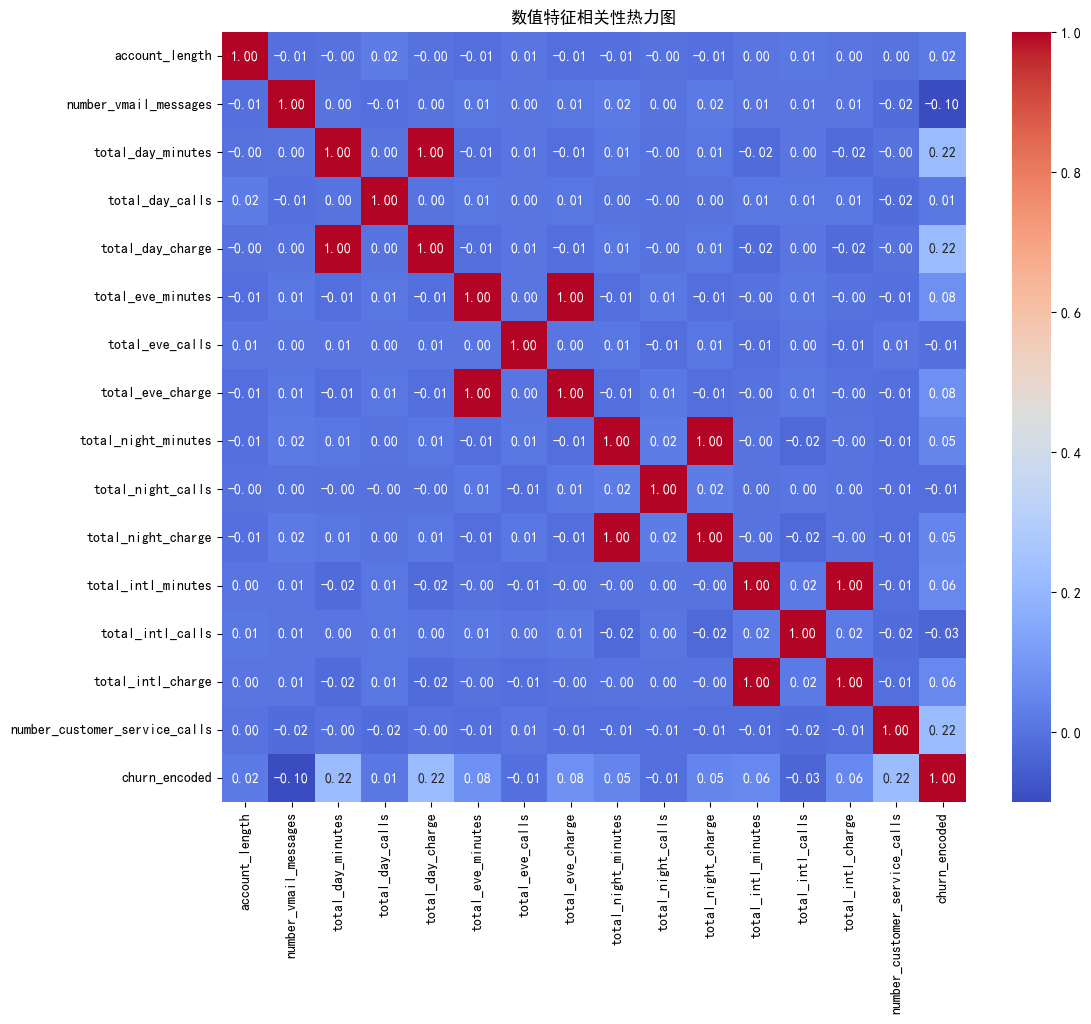

In [ ]:
#12.与流失率相关的特征分析
numeric_data=data.select_dtypes(include=[np.number])
correlation_matrix=numeric_data.corr()
correlations = correlation_matrix["churn_encoded"].drop("churn_encoded").sort_values(ascending=False)
print("与流失率相关的特征相关性：")
print(correlations)
#热力图
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("数值特征相关性热力图")
plt.show()



In [ ]:
#13.交叉分析高客服通话次数 + 高费用（日间费用>40美元）
high_calls_high_cost = data[(data["number_customer_service_calls"] > data["number_customer_service_calls"].quantile(0.75)) & (data["total_day_charge"] > 40)]
print(f"高客服通话次数 + 高费用的用户数量: {high_calls_high_cost.shape[0]}")
print(f"高客服通话次数 + 高费用的用户流失率: {high_calls_high_cost["churn_encoded"].mean():.2%}")   
#交叉分析高客服通话次数 + 国际套餐
high_calls_intl_plan = data[(data["number_customer_service_calls"] > data["number_customer_service_calls"].quantile(0.75)) & (data["international_plan"] == "yes")]
print(f"高客服通话次数 + 国际套餐的用户数量: {high_calls_intl_plan.shape[0]}")
print(f"高客服通话次数 + 国际套餐的用户流失率: {high_calls_intl_plan["churn_encoded"].mean():.2%}")

高客服通话次数 + 高费用的用户数量: 142
高客服通话次数 + 高费用的用户流失率: 36.62%
高客服通话次数 + 国际套餐的用户数量: 86
高客服通话次数 + 国际套餐的用户流失率: 53.49%


计算总费用后，数据集的前5行：
   total_day_charge  total_eve_charge  total_night_charge  total_intl_charge  \
0             27.47             16.62               11.45               3.70   
1             41.38             10.30                7.32               3.29   
2             50.90              5.26                8.86               1.78   
3             28.34             12.61                8.41               2.73   
4             37.09             29.62                9.57               2.03   

   total_charge  
0         59.24  
1         62.29  
2         66.80  
3         52.09  
4         78.31  
高危客户的流失率: 36.62%
核心客户的流失率: 39.49%
低频客户的流失率: 5.76%
问题客户的流失率: 24.10%


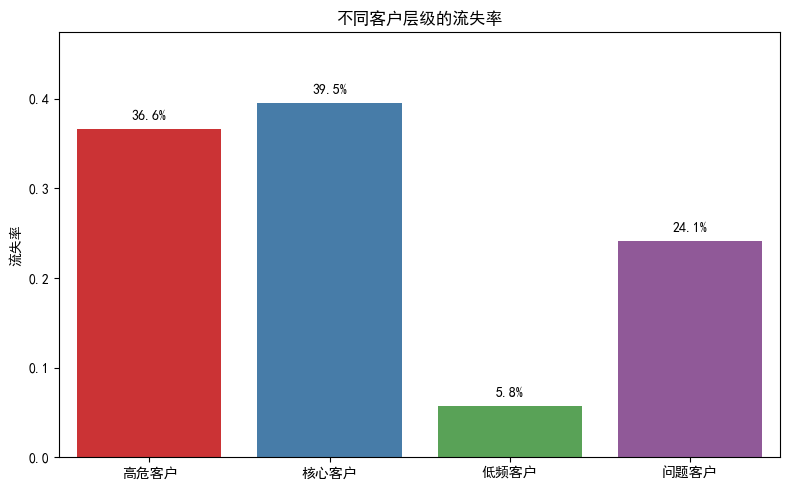

最终数据表包含列： ['state', 'account_length', 'area_code', 'international_plan', 'voice_mail_plan', 'number_vmail_messages', 'total_day_minutes', 'total_day_calls', 'total_day_charge', 'total_eve_minutes', 'total_eve_calls', 'total_eve_charge', 'total_night_minutes', 'total_night_calls', 'total_night_charge', 'total_intl_minutes', 'total_intl_calls', 'total_intl_charge', 'number_customer_service_calls', 'churn', 'churn_encoded', 'acct_len_group', 'total_charge', 'is_total_high_value', 'customer_tier', 'customer_segment', 'risk_flag']

数据维度： (4250, 27)

风险标志分布：
risk_flag
低风险    2848
中风险     751
高风险     651
Name: count, dtype: int64
已完成


In [ ]:
#14.PowerBI表 
##1.计算总费用
data["total_charge"] = data["total_day_charge"] + data["total_eve_charge"] + data["total_night_charge"] + data["total_intl_charge"]
print("计算总费用后，数据集的前5行：")
print(data[["total_day_charge", "total_eve_charge", "total_night_charge", "total_intl_charge", "total_charge"]].head())
#2.基于总费用进行客户分层
total_high_value=data["total_charge"].quantile(0.8)
total_medium_value=data["total_charge"].quantile(0.5)
data["is_total_high_value"]=data["total_charge"]>=total_high_value
data["customer_tier"]=pd.cut(data["total_charge"],bins=[0,total_medium_value,total_high_value,float("inf")],
                             labels=["低价值","中价值","高价值"])
#3.客户分群
conditions = [
    (data["total_day_charge"] > 40) & (data["number_customer_service_calls"] >= 3),  # 高危客户
    (data["total_day_charge"] > 40) & (data["number_customer_service_calls"] < 3),   # 核心客户
    (data["total_day_charge"] <= 40) & (data["number_customer_service_calls"] < 3),  # 低频客户
    (data["total_day_charge"] <= 40) & (data["number_customer_service_calls"] >= 3)   # 问题客户
]
chioces = ["高危客户", "核心客户", "低频客户", "问题客户"]
data["customer_segment"] = np.select(conditions, chioces, default="其他客户")
#4.分析不同客户层级的流失率
risk_churn_rate = data[data["customer_segment"] == "高危客户"]["churn_encoded"].mean()
core_churn_rate = data[data["customer_segment"] == "核心客户"]["churn_encoded"].mean()
low_freq_churn_rate = data[data["customer_segment"] == "低频客户"]["churn_encoded"].mean()
problem_churn_rate = data[data["customer_segment"] == "问题客户"]["churn_encoded"].mean()
print(f"高危客户的流失率: {risk_churn_rate:.2%}")
print(f"核心客户的流失率: {core_churn_rate:.2%}")
print(f"低频客户的流失率: {low_freq_churn_rate:.2%}")
print(f"问题客户的流失率: {problem_churn_rate:.2%}")
#5.可视化客户层级与流失率
customer_segments = ["高危客户", "核心客户", "低频客户", "问题客户"]
churn_rates = [risk_churn_rate, core_churn_rate, low_freq_churn_rate, problem_churn_rate]
plt.figure(figsize=(8, 5))
sns.barplot(x=customer_segments, y=churn_rates, palette="Set1")
plt.title("不同客户层级的流失率")
plt.ylabel("流失率")
plt.ylim(0, max(churn_rates) * 1.2)
for idx, rate in enumerate(churn_rates):
    plt.text(idx, rate + 0.01, f"{rate:.1%}", ha="center")
plt.tight_layout()
plt.show()
#6.风险等级
#高风险（流失率>30%）
#中风险（流失率>20%&流失率<=30%）
#低风险（流失率<=20%）
def assign_risk_flag(churn_rate):
    if churn_rate > 0.3:
        return "高风险"
    elif churn_rate > 0.2:
        return "中风险"
    else:
        return "低风险"
data["risk_flag"] = data["customer_segment"].map({
    "高危客户": assign_risk_flag(risk_churn_rate),
    "核心客户": assign_risk_flag(core_churn_rate),
    "低频客户": assign_risk_flag(low_freq_churn_rate),
    "问题客户": assign_risk_flag(problem_churn_rate)
})
#5.查看最终表结构
print("最终数据表包含列：",data.columns.tolist())
print("\n数据维度：",data.shape)
print("\n风险标志分布：")
print(data["risk_flag"].value_counts())
#6.导出单张宽度表到csv
data.to_csv(r"D:\Users\Desktop\客户流失预测\zuopin1.csv", index=False)
print("已完成")
